In [1]:
# ── Standard libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── XGBoost ──────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier
print("✓ XGBoost loaded!")
print("✓ All libraries loaded!")


✓ XGBoost loaded!
✓ All libraries loaded!


In [4]:
import pandas as pd

dataset_path = 'G:\Dementia\Starting\investigator_ftldlbd_nacc71.csv'

cols_needed = [
    'COGSTAT', 'NACCAGE', 'SEX', 'EDUC', 'NACCAPOE',
    'CDRGLOB', 'CDRSUM', 'NACCMOCA', 'TRAILA', 'TRAILB',
    'ANIMALS', 'VEG', 'MEMUNITS', 'DIGIF', 'DIGIB'
]

# Initialize an empty list to hold our data chunks
chunk_list = []

# Read the file in chunks of 100,000 rows
print("Loading data in chunks...")
for chunk in pd.read_csv(dataset_path, usecols=cols_needed, chunksize=100000, low_memory=True):
    chunk_list.append(chunk)

# Stitch all the chunks together into one DataFrame
df = pd.concat(chunk_list, ignore_index=True)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("✓ Data loading complete!")

Loading data in chunks...
Rows: 205,908 | Columns: 15
✓ Data loading complete!


In [5]:
# COGSTAT: 1=Normal, 2=Impaired-not-MCI, 3=MCI, 4=Dementia (AD)
df_clean = df[df['COGSTAT'].isin([1, 2, 3, 4])].copy()
df_clean['target_AD'] = (df_clean['COGSTAT'] == 4).astype(int)

print("Target Distribution (COGSTAT):")
print(f"  Non-AD      (0): {(df_clean['target_AD']==0).sum():,}")
print(f"  Alzheimer's (1): {(df_clean['target_AD']==1).sum():,}")
print(f"  AD Prevalence:   {df_clean['target_AD'].mean()*100:.2f}%")
print(f"\n✓ Target variable created!")


Target Distribution (COGSTAT):
  Non-AD      (0): 107,778
  Alzheimer's (1): 47,611
  AD Prevalence:   30.64%

✓ Target variable created!


In [6]:
features = [
    # Demographics
    'NACCAGE',      # Age at visit
    'SEX',          # 1=Male, 2=Female
    'EDUC',         # Years of education
    # Genetics
    'NACCAPOE',     # APOE genotype (0=e3/e3, 1=e3/e4, 2=e4/e4)
    # Clinical Dementia Rating
    'CDRGLOB',      # CDR Global Score
    'CDRSUM',       # CDR Sum of boxes  ← #1 feature
    # Cognitive Tests
    'NACCMOCA',     # MoCA (0-30)
    'TRAILA',       # Trail Making A (seconds)
    'TRAILB',       # Trail Making B (seconds)
    'ANIMALS',      # Verbal fluency: Animals
    'VEG',          # Verbal fluency: Vegetables
    'MEMUNITS',     # Memory units recalled
    'DIGIF',        # Digit Span Forward
    'DIGIB',        # Digit Span Backward
]

selected_features = [f for f in features if f in df_clean.columns]
print(f"Selected {len(selected_features)} features: {selected_features}\n")

X = df_clean[selected_features].copy()
y = df_clean['target_AD'].copy()

missing = X.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print("Missing values (filled with column median):")
    for col, cnt in missing.items():
        print(f"  {col}: {cnt:,} ({cnt/len(X)*100:.1f}%)")
X = X.fillna(X.median())

print(f"Dataset Shape:  {X.shape[0]:,} patients × {X.shape[1]} features")
print("✓ Data preparation complete!")


Selected 14 features: ['NACCAGE', 'SEX', 'EDUC', 'NACCAPOE', 'CDRGLOB', 'CDRSUM', 'NACCMOCA', 'TRAILA', 'TRAILB', 'ANIMALS', 'VEG', 'MEMUNITS', 'DIGIF', 'DIGIB']

Dataset Shape:  155,389 patients × 14 features
✓ Data preparation complete!


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} | Test set: {X_test.shape[0]:,}")
print("✓ Split & standardisation complete!")


Training set: 108,772 | Test set: 46,617
✓ Split & standardisation complete!


In [8]:

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    eval_metric='logloss',
    random_state=42
)
print("✓ XGBoost model defined!")

✓ XGBoost model defined!


In [9]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train_scaled, y_train,
                         cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost 5-Fold CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")
print("✓ Cross-validation complete!")

XGBoost 5-Fold CV ROC-AUC: 0.9564 ± 0.0011
✓ Cross-validation complete!


In [10]:

param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.10],
    'max_depth':     [3, 4],
    'subsample':     [0.8, 1.0],
}
grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)
model = grid_search.best_estimator_
print(f"✓ Best parameters: {grid_search.best_params_}")
print(f"  Best CV AUC:     {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
✓ Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
  Best CV AUC:     0.9569


In [11]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred,
      target_names=["Non-AD", "Alzheimer's"]))


Accuracy: 0.8992642169165755
              precision    recall  f1-score   support

      Non-AD       0.92      0.94      0.93     32334
 Alzheimer's       0.86      0.81      0.83     14283

    accuracy                           0.90     46617
   macro avg       0.89      0.87      0.88     46617
weighted avg       0.90      0.90      0.90     46617



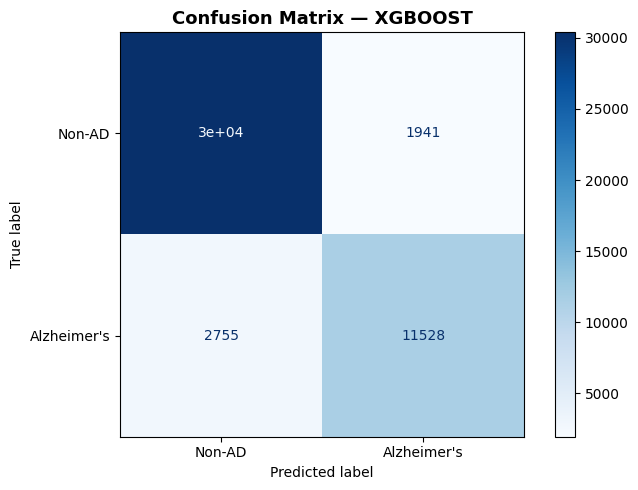

✓ Confusion matrix plotted!


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Non-AD", "Alzheimer's"],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — XGBOOST",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✓ Confusion matrix plotted!")


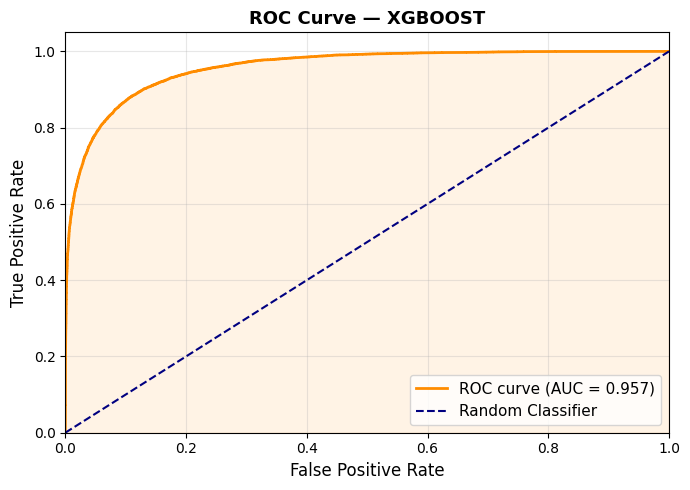

✓ ROC curve plotted!


In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC curve (AUC = {auc(fpr, tpr):.3f})')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--',
        label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title(f"ROC Curve — XGBOOST",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✓ ROC curve plotted!")



Feature Importance Ranking:
 Feature  Importance
  CDRSUM    0.640064
 CDRGLOB    0.071207
  TRAILB    0.062720
MEMUNITS    0.050409
 ANIMALS    0.038472
     VEG    0.037557
NACCMOCA    0.025995
   DIGIB    0.022670
   DIGIF    0.013233
 NACCAGE    0.012822
    EDUC    0.007375
NACCAPOE    0.006059
     SEX    0.005869
  TRAILA    0.005547


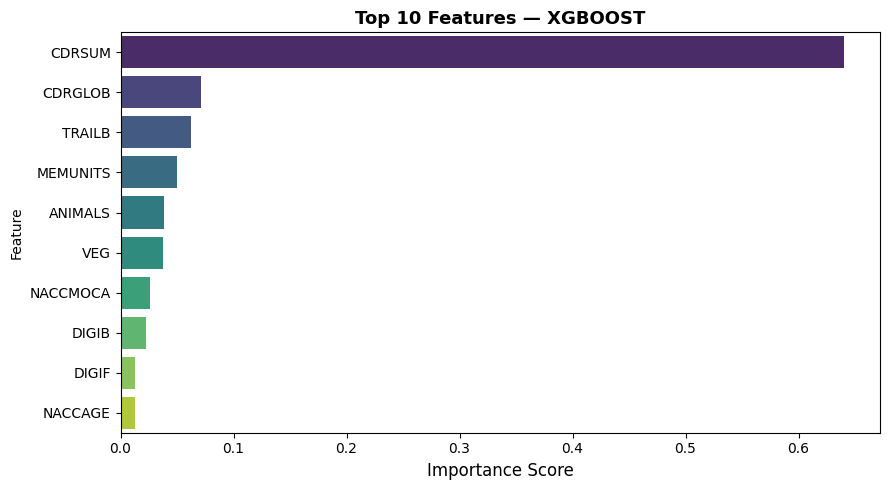


🔍 Key Insight: Top feature 'CDRSUM' accounts for 64.0% of model decisions


In [14]:
# Feature importance (works for tree-based models; skipped for LR)
if hasattr(model, 'feature_importances_'):
    feat_df = pd.DataFrame({
        'Feature':    selected_features,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nFeature Importance Ranking:")
    print(feat_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(x='Importance', y='Feature', data=feat_df.head(10),
                palette='viridis', ax=ax)
    ax.set_title(f"Top 10 Features — XGBOOST",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=12)
    plt.tight_layout()
    plt.show()

    top = feat_df.iloc[0]
    print(f"\n🔍 Key Insight: Top feature '{top['Feature']}' "
          f"accounts for {top['Importance']*100:.1f}% of model decisions")
else:
    print("Feature importances not available for Logistic Regression.")
    print("Use SHAP below for model-agnostic explanations.")


In [15]:
# REPLACE:
%pip install shap

# WITH:
try:
    import shap
except ImportError:
    %pip install shap -q

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.3 MB 12.0 MB/s eta 0:00:01
   ----------- ---------------------------- 3.7/12.3 MB 11.5 MB/s eta 0:00:01
   -------------------- ------------------- 6.3/12.3 MB 11.4 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.3 MB 11.5 MB/s eta 0:00:01
   ------------------------------------ --- 11.3/12.3 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 11.4 MB/s  0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.16.2 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.16.2 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


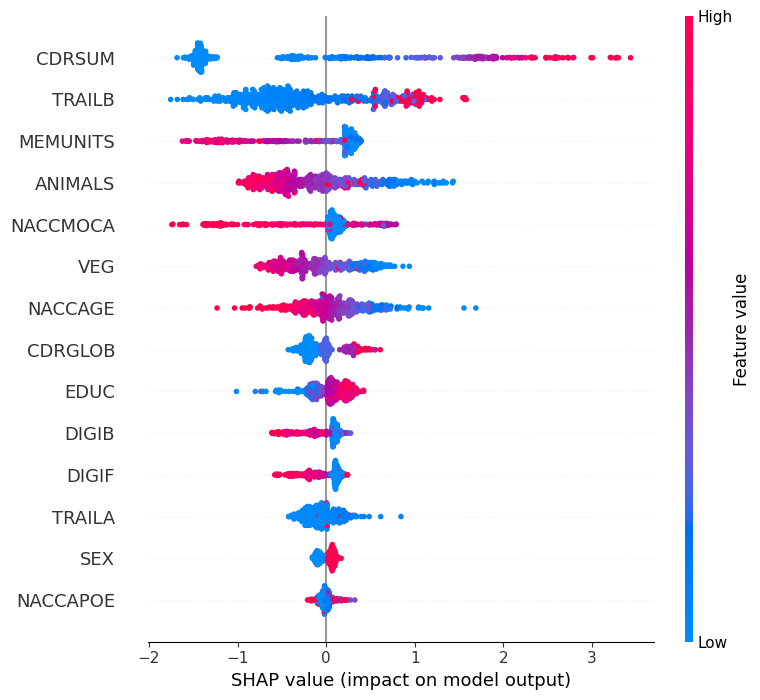

✓ SHAP summary plot shown!


In [16]:

try:
    import shap
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_scaled[:500])
    plt.figure()
    shap.summary_plot(shap_values, X_test_scaled[:500],
                      feature_names=selected_features, show=True)
    print("✓ SHAP summary plot shown!")
except ImportError:
    print("⚠ SHAP not installed.  Run:  pip install shap")
except Exception as e:
    print(f"⚠ SHAP error: {e}")


In [17]:
print("Decision Threshold Analysis:")
print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1':>8} | {'Accuracy':>10}")
print("-" * 58)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_t = (y_prob >= thresh).astype(int)
    p   = precision_score(y_test, y_t, zero_division=0)
    r   = recall_score(y_test, y_t)
    f   = f1_score(y_test, y_t, zero_division=0)
    acc = accuracy_score(y_test, y_t)
    print(f"{thresh:>10.1f} | {p:>10.4f} | {r:>10.4f} | {f:>8.4f} | {acc:>10.4f}")
print("\n💡 Lower threshold → higher recall (catches more AD cases)")
print("   Higher threshold → higher precision (fewer false alarms)")


Decision Threshold Analysis:
 Threshold |  Precision |     Recall |       F1 |   Accuracy
----------------------------------------------------------
       0.3 |     0.7712 |     0.8877 |   0.8253 |     0.8849
       0.4 |     0.8186 |     0.8482 |   0.8331 |     0.8959
       0.5 |     0.8559 |     0.8071 |   0.8308 |     0.8993
       0.6 |     0.8894 |     0.7589 |   0.8190 |     0.8972
       0.7 |     0.9175 |     0.7016 |   0.7952 |     0.8892

💡 Lower threshold → higher recall (catches more AD cases)
   Higher threshold → higher precision (fewer false alarms)


In [18]:
# Save the optimized XGBoost model
joblib.dump(model, 'clinical_xgb.pkl')

# Save the scaler to standardize new patient inputs during inference
joblib.dump(scaler, 'clinical_scaler.pkl')

# Save the feature names to ensure the input order matches perfectly
joblib.dump(selected_features, 'clinical_features.pkl')

print("✓ Model, scaler, and features saved successfully!")

✓ Model, scaler, and features saved successfully!
